<a href="https://colab.research.google.com/github/chaeminju/26-1IAP/blob/main/26_1IAP/models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 필수 라이브러리 설치 및 COCO 어노테이션 다운로드
!pip install -q tensorflow tensorflow-hub opencv-python ultralytics requests
!wget -nc -q http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -n -q annotations_trainval2017.zip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 57.0 MB/s eta 0:00:00


In [12]:
import json
import os
import random
import time
import urllib.request
import zipfile
import numpy as np
import cv2
import requests
import tensorflow as tf
import tensorflow_hub as hub
from ultralytics import YOLO

# 재현성을 위한 시드 고정
random.seed(42)

# ==========================================
# 0. 데이터셋 준비 (Annotation 및 이미지 다운로드)
# ==========================================
ANNOT_DIR = "annotations"
ANNOT_PATH = os.path.join(ANNOT_DIR, "person_keypoints_val2017.json")
SAVE_DIR = "images"

os.makedirs(ANNOT_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

# Annotation 파일이 없으면 COCO 공식 서버에서 다운로드
if not os.path.exists(ANNOT_PATH):
    print("COCO 어노테이션 파일이 없습니다. 다운로드를 시작합니다 (약 241MB)...")
    url = "http://images.cocodataset.org/annotations/annotations_trainval2017.zip"
    zip_path = "annotations.zip"
    urllib.request.urlretrieve(url, zip_path)
    print("압축 해제 중...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(".")
    os.remove(zip_path)
    print("어노테이션 준비 완료!\n")

with open(ANNOT_PATH, 'r') as f:
    data = json.load(f)

# 사람(keypoints)이 있는 이미지 샘플링
valid_image_ids = set([ann['image_id'] for ann in data['annotations'] if ann['num_keypoints'] > 0])
filtered_images = [img for img in data['images'] if img['id'] in valid_image_ids]

# [수정됨] 테스트 장수 변수화
NUM_SAMPLES = 500
sampled_images = random.sample(filtered_images, NUM_SAMPLES)

print(f"테스트용 이미지 {NUM_SAMPLES}장 준비 중...")
for img_info in sampled_images:
    file_name = img_info['file_name']
    img_path = os.path.join(SAVE_DIR, file_name)
    if not os.path.exists(img_path):
        img_data = requests.get(f"http://images.cocodataset.org/val2017/{file_name}").content
        with open(img_path, 'wb') as f:
            f.write(img_data)
print("다운로드 완료!\n")

# ==========================================
# 1. 평가 지표 함수 정의 (정확도 및 속도)
# ==========================================
COCO_SIGMAS = np.array([0.026, 0.025, 0.025, 0.035, 0.035, 0.079, 0.079, 0.072, 0.072, 0.062, 0.062, 0.107, 0.107, 0.087, 0.087, 0.089, 0.089])

def compute_oks(pred_kp, gt_kp, bbox_area):
    if pred_kp is None or len(pred_kp) == 0: return 0.0
    oks_sum, valid_count = 0, 0
    for i in range(17):
        gt_x, gt_y, vis = gt_kp[i]
        if vis > 0:
            pred_x, pred_y = pred_kp[i][0], pred_kp[i][1]
            dist_sq = (pred_x - gt_x)**2 + (pred_y - gt_y)**2
            kappa = 2 * (COCO_SIGMAS[i] ** 2)
            oks_sum += np.exp(-dist_sq / (2 * bbox_area * kappa))
            valid_count += 1
    return oks_sum / valid_count if valid_count > 0 else 0.0

def compute_detailed_pck(pred_kp, gt_kp, bbox, threshold=0.1):
    if pred_kp is None or len(pred_kp) == 0: return 0.0, 0.0
    norm = max(bbox[2], bbox[3])
    c_vis, t_vis, c_occ, t_occ = 0, 0, 0, 0

    for i in range(17):
        gt_x, gt_y, vis = gt_kp[i]
        if vis > 0:
            dist = np.linalg.norm([pred_kp[i][0] - gt_x, pred_kp[i][1] - gt_y])
            is_correct = dist < (threshold * norm)
            if vis == 2:
                t_vis += 1
                if is_correct: c_vis += 1
            elif vis == 1:
                t_occ += 1
                if is_correct: c_occ += 1
    pck_vis = (c_vis / t_vis) if t_vis > 0 else 1.0
    pck_occ = (c_occ / t_occ) if t_occ > 0 else 1.0
    return pck_vis, pck_occ

def measure_fps(func, *args, repeat=5):
    times = []
    for _ in range(repeat):
        start = time.time()
        func(*args)
        times.append(time.time() - start)
    return 1 / np.mean(times)

# ==========================================
# 2. 다중 모델 로드 세팅
# ==========================================
print("모델들을 메모리에 로드하는 중입니다 (시간이 조금 걸릴 수 있습니다)...")

# MoveNet 로드
movenet_model = hub.load("https://tfhub.dev/google/movenet/singlepose/lightning/4")
movenet = movenet_model.signatures['serving_default']

def run_movenet(image_path, img_width, img_height):
    img = cv2.imread(image_path)
    img_resized = cv2.resize(img, (192, 192))
    input_tensor = tf.cast(tf.expand_dims(img_resized, axis=0), dtype=tf.int32)
    outputs = movenet(input_tensor)
    keypoints = outputs['output_0'].numpy()[0, 0]
    abs_kp = [[x * img_width, y * img_height, score] for y, x, score in keypoints]
    return np.array(abs_kp)

# 여러 YOLO 모델 로드
yolo_models = {
    'YOLOv8-Pose (Nano)': YOLO('yolov8n-pose.pt'),
    'YOLOv8-Pose (Small)': YOLO('yolov8s-pose.pt')
}

def run_yolo_pose(model, image_path):
    results = model(image_path, verbose=False)
    if results[0].keypoints is not None and len(results[0].keypoints.data) > 0:
        return results[0].keypoints.data[0].cpu().numpy()
    return None

# 결과 저장을 위한 딕셔너리 세팅
metrics = {
    'MoveNet': {'fps': [], 'oks': [], 'pck_vis': [], 'pck_occ': [], 'misses': 0}
}
for name in yolo_models.keys():
    metrics[name] = {'fps': [], 'oks': [], 'pck_vis': [], 'pck_occ': [], 'misses': 0}

# ==========================================
# 3. 종합 평가 루프
# ==========================================
print(f"\n========== 다중 모델 속도 및 정확도 벤치마크 시작 ({NUM_SAMPLES}장) ==========")

for i, img_info in enumerate(sampled_images):
    path = os.path.join(SAVE_DIR, img_info['file_name'])
    w, h = img_info['width'], img_info['height']

    # 정답(GT) 정보 추출
    gt_anns = [ann for ann in data['annotations'] if ann['image_id'] == img_info['id'] and ann['num_keypoints'] > 0]
    if not gt_anns: continue

    best_ann = max(gt_anns, key=lambda x: x['bbox'][2] * x['bbox'][3])
    gt_kp = np.array(best_ann['keypoints']).reshape(-1, 3)
    bbox = best_ann['bbox']
    area = best_ann['area']

    # 워밍업
    if i == 0:
        run_movenet(path, w, h)
        for model in yolo_models.values():
            run_yolo_pose(model, path)

    # 1. MoveNet 평가
    m_pred = run_movenet(path, w, h)
    metrics['MoveNet']['fps'].append(measure_fps(run_movenet, path, w, h))
    if m_pred is None:
        metrics['MoveNet']['misses'] += 1
    else:
        metrics['MoveNet']['oks'].append(compute_oks(m_pred, gt_kp, area))
        p_vis, p_occ = compute_detailed_pck(m_pred, gt_kp, bbox)
        metrics['MoveNet']['pck_vis'].append(p_vis)
        metrics['MoveNet']['pck_occ'].append(p_occ)

    # 2. YOLOv8 다중 평가 루프
    for name, model in yolo_models.items():
        y_pred = run_yolo_pose(model, path)
        metrics[name]['fps'].append(measure_fps(run_yolo_pose, model, path))
        if y_pred is None:
            metrics[name]['misses'] += 1
        else:
            metrics[name]['oks'].append(compute_oks(y_pred, gt_kp, area))
            p_vis, p_occ = compute_detailed_pck(y_pred, gt_kp, bbox)
            metrics[name]['pck_vis'].append(p_vis)
            metrics[name]['pck_occ'].append(p_occ)

    if (i + 1) % 100 == 0:
        print(f" ... [{i + 1}/{NUM_SAMPLES}] 평가 완료")

# ==========================================
# 4. 최종 결과 출력 함수
# ==========================================
def print_report(name, data_dict):
    total_attempts = len(data_dict['fps']) + data_dict['misses']
    avg_fps = np.mean(data_dict['fps']) if data_dict['fps'] else 0.0
    miss_rate = (data_dict['misses'] / total_attempts) * 100 if total_attempts > 0 else 0.0
    avg_oks = np.mean(data_dict['oks']) * 100 if data_dict['oks'] else 0.0
    pck_v = np.mean(data_dict['pck_vis']) * 100 if data_dict['pck_vis'] else 0.0
    pck_o = np.mean(data_dict['pck_occ']) * 100 if data_dict['pck_occ'] else 0.0

    print(f"\n[{name}]")
    print(f" ====================속도 관점=====================")
    print(f"    - 평균 처리 속도 : {avg_fps:.1f} FPS")
    print(f"    - 객체 탐지 실패율: {miss_rate:.1f} %")
    print(f" ===========정확도 관점 (높을수록 좋음)=============")
    print(f"    - OKS 종합 점수  : {avg_oks:.1f} 점")
    print(f"    - PCK (보이는 관절): {pck_v:.1f} %")
    print(f"    - PCK (가려진 관절): {pck_o:.1f} %")

print("\n" + "="*50)
print(" 속도 및 정확도 통합 벤치마크 최종 리포트 ")
print("="*50)
for name, data_dict in metrics.items():
    print_report(name, data_dict)
    print("-" * 50)

테스트용 이미지 500장 준비 중...
다운로드 완료!

모델들을 메모리에 로드하는 중입니다 (시간이 조금 걸릴 수 있습니다)...

========== 다중 모델 속도 및 정확도 벤치마크 시작 (500장) ==========
 ... [100/500] 평가 완료
 ... [200/500] 평가 완료
 ... [300/500] 평가 완료
 ... [400/500] 평가 완료
 ... [500/500] 평가 완료

 속도 및 정확도 통합 벤치마크 최종 리포트 

[MoveNet]
 ====================속도 관점=====================
    - 평균 처리 속도 : 44.9 FPS
    - 객체 탐지 실패율: 0.0 %
 ===========정확도 관점 (높을수록 좋음)=============
    - OKS 종합 점수  : 31.9 점
    - PCK (보이는 관절): 48.4 %
    - PCK (가려진 관절): 71.5 %
--------------------------------------------------

[YOLOv8-Pose (Nano)]
 ====================속도 관점=====================
    - 평균 처리 속도 : 38.5 FPS
    - 객체 탐지 실패율: 1.4 %
 ===========정확도 관점 (높을수록 좋음)=============
    - OKS 종합 점수  : 57.6 점
    - PCK (보이는 관절): 72.3 %
    - PCK (가려진 관절): 82.3 %
--------------------------------------------------

[YOLOv8-Pose (Small)]
 ====================속도 관점=====================
    - 평균 처리 속도 : 37.7 FPS
    - 객체 탐지 실패율: 0.8 %
 ===========정확도 관점 (높을수록 좋음)=============
    - 

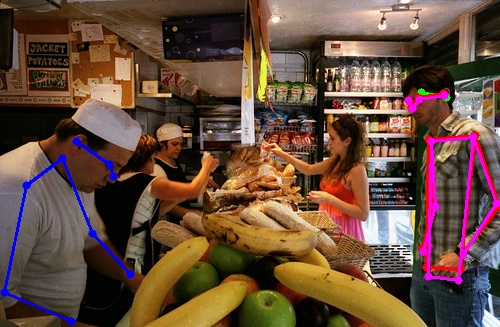

In [13]:
import cv2
import os
import numpy as np
from PIL import Image as PILImage
from IPython.display import display, Image

# ===== skeleton 정의 =====
COCO_SKELETON = [
    (0,1),(0,2),(1,3),(2,4),
    (5,6),(5,7),(7,9),(6,8),(8,10),
    (5,11),(6,12),(11,12),
    (11,13),(13,15),(12,14),(14,16)
]

def draw_skeleton(img, keypoints, color, label, threshold=0.3):
    """
    이미지에 스켈레톤을 그리는 함수
    """
    for x, y, score in keypoints:
        if score > threshold:
            cv2.circle(img, (int(x), int(y)), 4, color, -1)

    for i, j in COCO_SKELETON:
        if keypoints[i][2] > threshold and keypoints[j][2] > threshold:
            pt1 = (int(keypoints[i][0]), int(keypoints[i][1]))
            pt2 = (int(keypoints[j][0]), int(keypoints[j][1]))
            cv2.line(img, pt1, pt2, color, 2)

def visualize_comparison(image_path, gt_kp, movenet_kp, yolo_nano_kp, yolo_small_kp):
    img = cv2.imread(image_path)

    # 색상 정의 (BGR 순서)
    draw_skeleton(img, gt_kp, (255, 0, 0), "GT")                  # 파란색
    draw_skeleton(img, movenet_kp, (0, 255, 0), "MoveNet")        # 초록색

    if yolo_nano_kp is not None:
        draw_skeleton(img, yolo_nano_kp, (0, 0, 255), "YOLO-Nano") # 빨간색

    if yolo_small_kp is not None:
        # Small 모델은 보라색(Magenta)으로 표시
        draw_skeleton(img, yolo_small_kp, (255, 0, 255), "YOLO-Small")

    save_path = "/content/compare_v2.jpg"
    cv2.imwrite(save_path, img)
    return save_path

# ===== 실행부 =====
img_info = sampled_images[0]
path = os.path.join(SAVE_DIR, img_info['file_name'])
w, h = img_info['width'], img_info['height']

# 1. GT 데이터 추출
gt_anns = [ann for ann in data['annotations'] if ann['image_id'] == img_info['id'] and ann['num_keypoints'] > 0]
best_ann = max(gt_anns, key=lambda x: x['bbox'][2] * x['bbox'][3])
gt_kp = np.array(best_ann['keypoints']).reshape(-1, 3)

# 2. 각 모델별 추론
# MoveNet
m_kp = run_movenet(path, w, h)

# YOLOv8-Pose Nano
y_nano_kp = run_yolo_pose(yolo_models['YOLOv8-Pose (Nano)'], path)

# YOLOv8-Pose Small (모델 딕셔너리에 'Small'이 정의되어 있다고 가정)
y_small_kp = run_yolo_pose(yolo_models['YOLOv8-Pose (Small)'], path)

# 3. 결과 시각화 및 저장
out_path = visualize_comparison(path, gt_kp, m_kp, y_nano_kp, y_small_kp)

# 4. 출력
display(Image(out_path))